In [7]:
import pandas as pd

# Load the dataset
df = pd.read_csv('q1_heart_disease.csv')

# 1. Shape of the dataset
print("Dataset Shape:", df.shape)

# 2. Data Types
print("\nData Types:\n", df.dtypes)

# 3. Missing Value Counts
print("\nMissing Value Counts:\n", df.isnull().sum())

# 4. First Five Rows
print("\nFirst 5 Rows:\n", df.head())

Dataset Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Value Counts:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 Rows:
    age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72    1     asymptomatic  

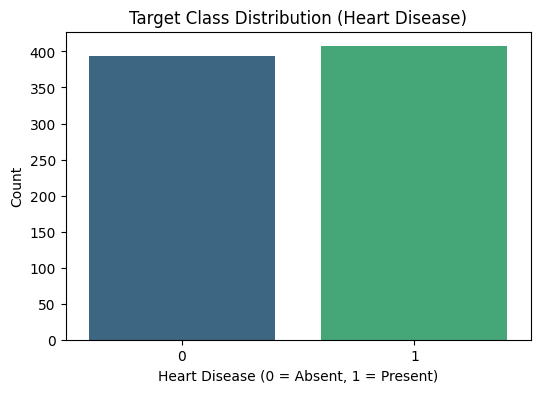

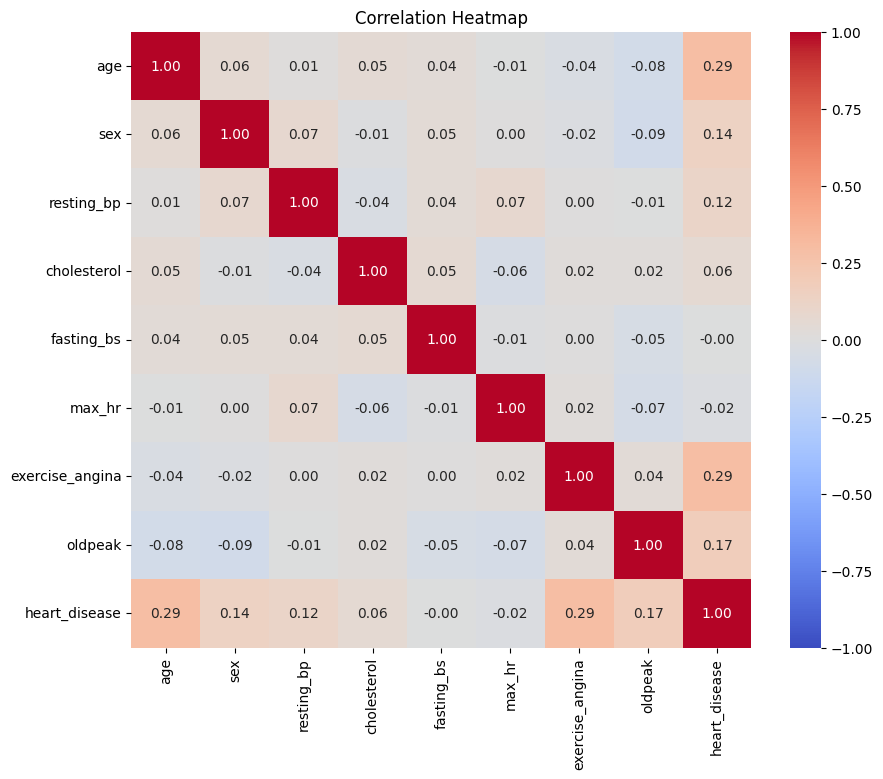

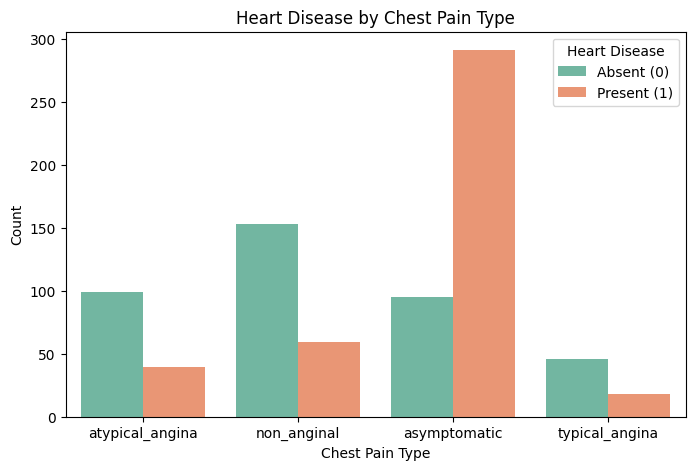

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline

# 1. Target Class Distribution Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='heart_disease', data=df, hue='heart_disease', palette='viridis', legend=False)
plt.title('Target Class Distribution (Heart Disease)')
plt.xlabel('Heart Disease (0 = Absent, 1 = Present)')
plt.ylabel('Count')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))

numerical_cols = ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak', 'heart_disease']
corr = df[numerical_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

# 3. Chest Pain Type vs Heart Disease
plt.figure(figsize=(8, 5))
sns.countplot(x='chest_pain_type', hue='heart_disease', data=df, palette='Set2')
plt.title('Heart Disease by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.legend(title='Heart Disease', labels=['Absent (0)', 'Present (1)'])
plt.show()


## Interpretation 1: Target Class Distribution
The target class distribution plot reveals that the dataset is highly balanced. There are almost an equal number of patients with heart disease (1) and without heart disease (0) in the dataset. This is an excellent property for training classification models, as it implies we will not need to artificially re-balance the dataset before training.

## Interpretation 2: Correlation Heatmap
The correlation heatmap reveals how numerical features relate to each other and the target variable:

Strongest Positive Correlates: exercise_angina (0.29), age (0.29), and oldpeak (0.17) show the highest positive correlation with heart_disease. This logically implies that older patients and patients who experience angina during exercise are more likely to have heart disease.

Weak Correlates: Features like fasting_bs (-0.00) and max_hr (-0.02) have almost no linear correlation with the target variable in this specific dataset.

Multicollinearity: There are no strongly correlated pairs among the independent variables. This means we don't have to worry heavily about multicollinearity interfering with models like Logistic Regression.

##Interpretation 3: Heart Disease by Chest Pain Type
This grouped bar chart uncovers a very strong relationship between the type of chest pain and the presence of heart disease:

Asymptomatic Patients: A vast majority of the patients who actually have heart disease present as "asymptomatic".

Non-Anginal and Atypical Angina: Interestingly, patients experiencing "non-anginal" and "atypical angina" chest pains are predominantly in the healthy category (Heart Disease = 0).
This tells us that chest_pain_type is likely going to be one of the most important predictive features for our machine learning models.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('q1_heart_disease.csv')

# 1.  To Handle missing values (Median Imputation)
df['resting_bp'] = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

# 2.Using drop_first=True to avoid the dummy variable trap
categorical_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3. To define features (X) and target (y)
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

# 4. To Split data using train_test_split
# We use a standard 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 5. To Scale numerical features using StandardScaler
num_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']
scaler = StandardScaler()

# To Fit on training data and transform both
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Display the resulting shapes to verify
print("Preprocessing Complete!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of missing values remaining:", X_train.isnull().sum().sum())

Preprocessing Complete!
X_train shape: (640, 15)
X_test shape: (160, 15)
Number of missing values remaining: 0


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Note: This code assumes X_train, X_test, y_train, and y_test exist in memory
# from the successful execution of Task 3.

# 1. Initializing and training the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree Model trained successfully.")

# 2. Initializing and training the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Model trained successfully.")

# 3. Initializing and training the Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
print("Gradient Boosting Model trained successfully.")

# Optional: Let's check the training accuracy to ensure they learned from the data
print("\n--- Training Accuracies ---")
print(f"Decision Tree: {dt_model.score(X_train, y_train):.4f}")
print(f"Random Forest: {rf_model.score(X_train, y_train):.4f}")
print(f"Gradient Boosting: {gb_model.score(X_train, y_train):.4f}")

Decision Tree Model trained successfully.
Random Forest Model trained successfully.
Gradient Boosting Model trained successfully.

--- Training Accuracies ---
Decision Tree: 1.0000
Random Forest: 1.0000
Gradient Boosting: 0.9609


In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Dictionary of our trained models
models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}


for name, model in models.items():
    # 1. Make predictions on the test set
    y_pred = model.predict(X_test)

    # 2. Calculating metrics
    cm = confusion_matrix(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # 3. Printing the results
    print(f"--- {name} ---")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}\n")

--- Decision Tree ---
Confusion Matrix:
[[57 22]
 [25 56]]
Precision: 0.7179
Recall:    0.6914
F1-Score:  0.7044

--- Random Forest ---
Confusion Matrix:
[[61 18]
 [15 66]]
Precision: 0.7857
Recall:    0.8148
F1-Score:  0.8000

--- Gradient Boosting ---
Confusion Matrix:
[[61 18]
 [19 62]]
Precision: 0.7750
Recall:    0.7654
F1-Score:  0.7702



In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Defining the parameter grid to search through
param_grid = {
    'n_estimators': [50, 100, 200],         # Number of trees
    'max_depth': [None, 5, 10, 15],         # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],        # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]           # Minimum samples required to be at a leaf node
}

# 2. Initializing GridSearchCV
# We use scoring='f1' since F1-score was our deciding metric
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,            # 5-fold cross-validation
    scoring='f1',
    n_jobs=-1        # Use all available CPU cores for faster computation
)

# 3. Fitting the model to find the best parameters
print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

# 4. Extracting the best model and evaluate it on the test set
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

# Calculating new metrics
tuned_prec = precision_score(y_test, y_pred_tuned)
tuned_rec = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

# 5. Outputting the results
print("\nBest Parameters Found:", grid_search.best_params_)

print("\n--- Baseline Random Forest (Untuned) ---")
print(f"Precision: 0.7857")
print(f"Recall:    0.8148")
print(f"F1-Score:  0.8000")

print("\n--- Tuned Random Forest ---")
print(f"Precision: {tuned_prec:.4f}")
print(f"Recall:    {tuned_rec:.4f}")
print(f"F1-Score:  {tuned_f1:.4f}")

Starting Grid Search...

Best Parameters Found: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

--- Baseline Random Forest (Untuned) ---
Precision: 0.7857
Recall:    0.8148
F1-Score:  0.8000

--- Tuned Random Forest ---
Precision: 0.7444
Recall:    0.8272
F1-Score:  0.7836
